In [ ]:
# 1. Import libs

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [6]:
housing = fetch_california_housing()

# Create a dataframe
df = pd.DataFrame(housing.data, columns=housing.feature_names)

df["MedHouseVal"] = housing.target

df.head(5)
df.count

<bound method DataFrame.count of        MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
...       ...       ...       ...        ...         ...       ...       ...   
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   

      

In [7]:
df.isnull().sum()


MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [8]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [10]:
# define features and target variable
x = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

# split the data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=25)

print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)

(14448, 8) (6192, 8) (14448,) (6192,)


# Create and Fit the model

In [11]:
model = LinearRegression()

# Fit the model
model.fit(x_train, y_train)

print("Intersept:", model.intercept_)
print("Coefficients:", model.coef_)

Intersept: -37.55216631658928
Coefficients: [ 4.41181942e-01  9.70730794e-03 -1.19993946e-01  7.84709051e-01
 -3.39466724e-07 -3.28239095e-03 -4.23679731e-01 -4.39311822e-01]


# Make prediction

In [12]:
y_pred = model.predict(x_test)

# Visualize the prediction

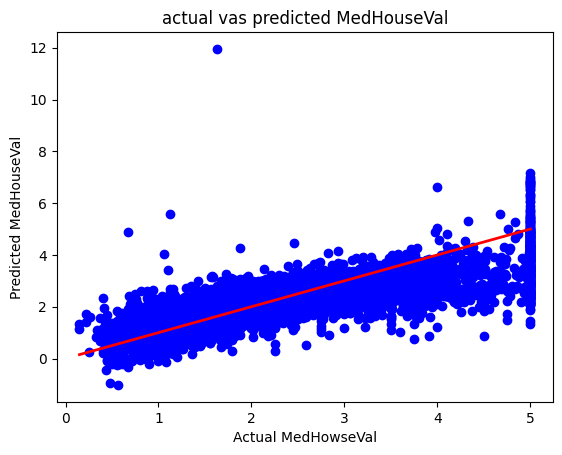

In [18]:
plt.scatter(y_test, y_pred, color="blue")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linewidth=2)
plt.xlabel("Actual MedHowseVal")
plt.ylabel("Predicted MedHouseVal")
plt.title("actual vas predicted MedHouseVal")
plt.show()

# Evaluate the model

In [26]:
# Mean Squared Error
mse = mean_squared_error(y_test, y_pred)

# R-squared
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")

Mean Squared Error: 0.54
R-squared: 0.60
